In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
# Importing dataset and examining it
dataset = pd.read_csv("online_shoppers_intention.csv")
pd.set_option('display.max_columns', None) # to make sure you can see all the columns in output window
print(dataset.head())
print(dataset.shape)
print(dataset.info())
print(dataset.describe())

   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0         0.0   Feb   

In [ ]:
# Missing values in dataset
dataset.isna().sum()

# Duplicates may be present
dataset.duplicated().sum()

np.int64(125)

In [ ]:
# Examine duplicates
dataset[dataset.duplicated(keep=False)].head()



,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
85,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
132,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
158,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
178,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False


In [ ]:
# Drop the duplicates
dataset = dataset.drop_duplicates()

In [ ]:
# Check for invalid values. Step recommended by ChatGPT
print((dataset[['BounceRates', 'ExitRates', 'SpecialDay']] < 0).sum())
print((dataset[['BounceRates', 'ExitRates', 'SpecialDay']] > 1).sum())
print((
    dataset[
        ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']
    ]
    < 0
).sum())

BounceRates    0
ExitRates      0
SpecialDay     0
dtype: int64
BounceRates    0
ExitRates      0
SpecialDay     0
dtype: int64
Administrative_Duration    0
Informational_Duration     0
ProductRelated_Duration    0
dtype: int64


In [ ]:
# Check for dataset balance. Target value is imbalanced
print(dataset['Revenue'].value_counts(normalize=True))
print(dataset['Revenue'].value_counts())

Revenue
False    0.843671
True     0.156329
Name: proportion, dtype: float64
Revenue
False    10297
True      1908
Name: count, dtype: int64


In [ ]:
# PageValues correlates to revenue. People with high PageValues purchase more.
print(dataset.groupby('Revenue')['PageValues'].mean())
print(dataset.groupby('Revenue')['ProductRelated_Duration'].mean())

Revenue
False     1.999985
True     27.264518
Name: PageValues, dtype: float64
Revenue
False    1082.976881
True     1876.209615
Name: ProductRelated_Duration, dtype: float64


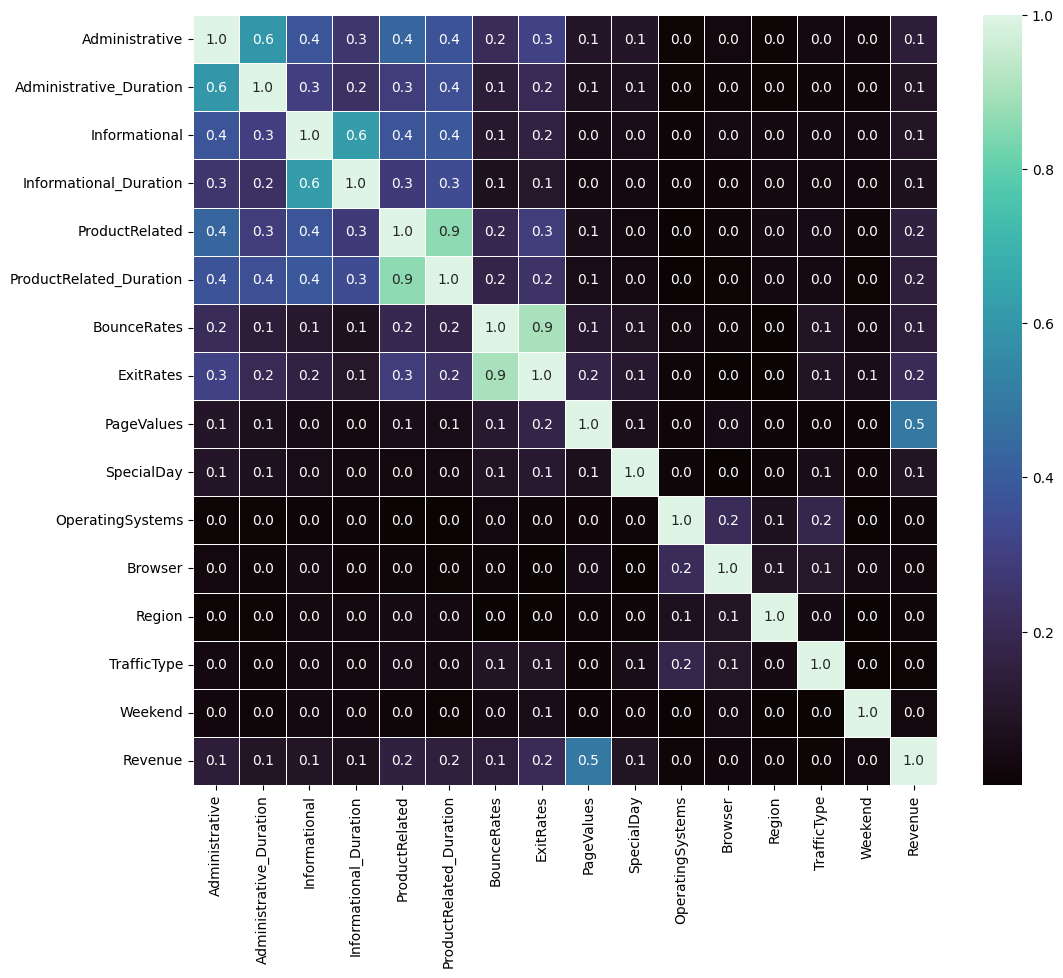

In [ ]:
# Examine correlation between values
import matplotlib.pyplot as plt
import seaborn as sns

corr = dataset.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(
    np.abs(corr),
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cmap='mako',
)
plt.show()

In [ ]:
dataset.nunique().sort_values()



,0
Revenue,2
Weekend,2
VisitorType,3
SpecialDay,6
OperatingSystems,8
Region,9
Month,10
Browser,13
Informational,17
TrafficType,20


In [ ]:
# Converting categorical features into numerical features
dataset = pd.get_dummies(dataset, columns=['Month', 'VisitorType'], drop_first=True)

# Converting boolean columns to integer
dataset['Weekend'] = dataset['Weekend'].astype(int)
dataset['Revenue'] = dataset['Revenue'].astype(int)

print(dataset.info())
print(dataset.head())

<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12205 non-null  int64  
 1   Administrative_Duration        12205 non-null  float64
 2   Informational                  12205 non-null  int64  
 3   Informational_Duration         12205 non-null  float64
 4   ProductRelated                 12205 non-null  int64  
 5   ProductRelated_Duration        12205 non-null  float64
 6   BounceRates                    12205 non-null  float64
 7   ExitRates                      12205 non-null  float64
 8   PageValues                     12205 non-null  float64
 9   SpecialDay                     12205 non-null  float64
 10  OperatingSystems               12205 non-null  int64  
 11  Browser                        12205 non-null  int64  
 12  Region                         12205 non-null  int6

In [ ]:
# Create feature matrix X and target vector y
X = dataset.drop('Revenue', axis=1)
y = dataset['Revenue']

# Verify shapes
print(f'Shape of X: {X.shape}')
print(f'Shape of y: {y.shape}')
print(dataset.head())


Shape of X: (12205, 26)
Shape of y: (12205,)
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay  OperatingSystems  Browser  \
0         0.20       0.20         0.0         0.0                 1        1   
1      

In [ ]:

# Normalizing numerical features so that each feature has mean 0 and variance 1
feature_scaler = StandardScaler()
X_scaled = feature_scaler.fit_transform(X)

In [ ]:
# Implementing Random Forest Classifier
# Tuning the random forest parameters 'n_estimators', 'max_depth' and implementing cross-validation using Grid Search
model = Pipeline([
        ('balancing', SMOTE(random_state = 101)),
        ('classification', RandomForestClassifier(criterion='entropy', max_features='sqrt', random_state=1) )
    ])
grid_param = {
    'classification__n_estimators': [10,50,100],
    'classification__max_depth': [None, 20],
    'balancing__k_neighbors': [3, 5, 7] # Hyperparameter for SMOTE
    }

gd_sr = GridSearchCV(estimator=model, param_grid=grid_param, scoring='recall', cv=5, n_jobs=-1)

In [ ]:

gd_sr.fit(X_scaled, y)

best_parameters = gd_sr.best_params_
print(best_parameters)

best_result = gd_sr.best_score_ # Mean cross-validated score of the best_estimator
print(best_result)

featimp = pd.Series(gd_sr.best_estimator_.named_steps["classification"].feature_importances_, index=list(X)).sort_values(ascending=False) # Getting feature importances list for the best model
print(featimp)


{'balancing__k_neighbors': 7, 'classification__max_depth': 20, 'classification__n_estimators': 100}
0.7311868738920724
PageValues                       0.377640
Administrative                   0.073464
ExitRates                        0.073041
ProductRelated_Duration          0.061750
ProductRelated                   0.058079
Administrative_Duration          0.047256
TrafficType                      0.046180
BounceRates                      0.039248
OperatingSystems                 0.032904
Month_Nov                        0.032378
Region                           0.031447
Browser                          0.022467
Informational                    0.020548
Informational_Duration           0.017078
Month_May                        0.016065
VisitorType_Returning_Visitor    0.012288
Month_Mar                        0.008907
Weekend                          0.008226
Month_Dec                        0.005307
Month_Sep                        0.004434
SpecialDay                       0.003831

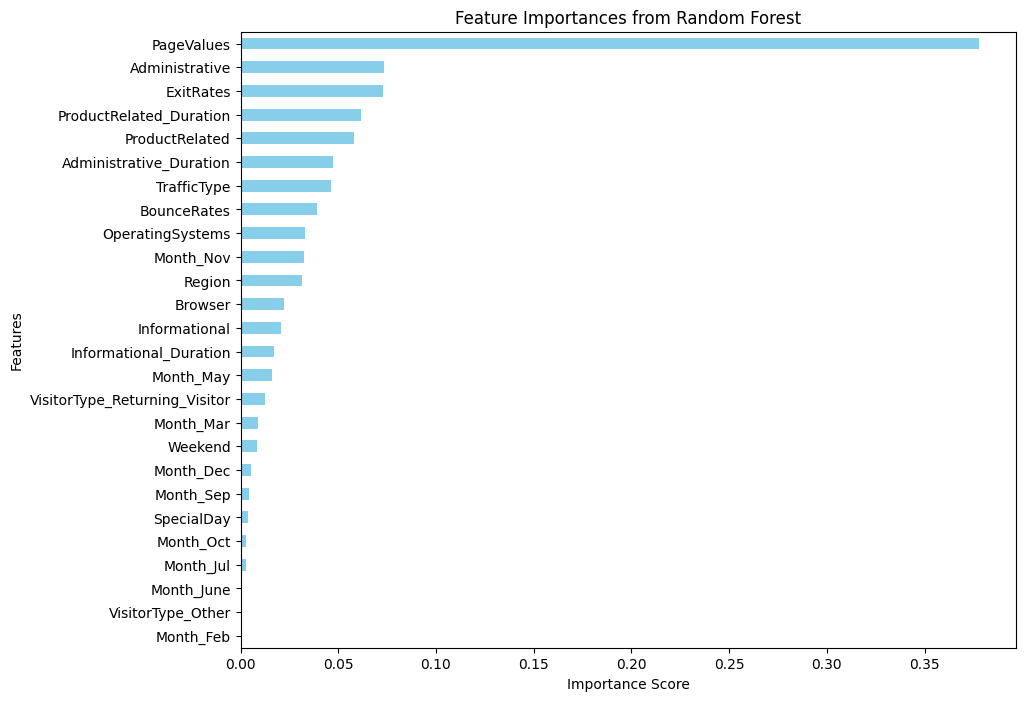

Number of features selected: 16
Selected Significant Features:
1. PageValues
2. Administrative
3. ExitRates
4. ProductRelated_Duration
5. ProductRelated
6. Administrative_Duration
7. TrafficType
8. BounceRates
9. OperatingSystems
10. Month_Nov
11. Region
12. Browser
13. Informational
14. Informational_Duration
15. Month_May
16. VisitorType_Returning_Visitor


In [ ]:
# Examine featimp and visualize for better threshold selection
plt.figure(figsize=(10, 8))
featimp.plot(kind='barh', color='skyblue')
plt.title('Feature Importances from Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.show()

# Define a threshold or select top N features
# Given the drop after the first few features, we will select features with importance > 0.01
threshold = 0.01
selected_features = featimp[featimp > threshold].index.tolist()

# Create a list containing the names of these selected features
print(f"Number of features selected: {len(selected_features)}")

# Print the list of selected features
print("Selected Significant Features:")
for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")

In [ ]:
from sklearn.model_selection import train_test_split

# Filter original feature matrix X to include only selected features
X_refined = X[selected_features]

# Split refined data into training and testing sets
# Using a common random_state=42 and test_size=0.2 for consistency
X_train, X_test, y_train, y_test = train_test_split(X_refined, y, test_size=0.2, random_state=42, stratify=y)

# Display shape and first few rows to verify
print(f"Shape of X_refined: {X_refined.shape}")
print("\nFirst 5 rows of X_refined:")
print(X_refined.head())

print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Shape of X_refined: (12205, 16)

First 5 rows of X_refined:
   PageValues  Administrative  ExitRates  ProductRelated_Duration  \
0         0.0               0       0.20                 0.000000   
1         0.0               0       0.10                64.000000   
2         0.0               0       0.20                 0.000000   
3         0.0               0       0.14                 2.666667   
4         0.0               0       0.05               627.500000   

   ProductRelated  Administrative_Duration  TrafficType  BounceRates  \
0               1                      0.0            1         0.20   
1               2                      0.0            2         0.00   
2               1                      0.0            3         0.20   
3               2                      0.0            4         0.05   
4              10                      0.0            4         0.02   

   OperatingSystems  Month_Nov  Region  Browser  Informational  \
0                 1      F

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Define the pipeline
refined_model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('balancing', SMOTE(random_state=101)),
    ('classification', RandomForestClassifier(criterion='entropy', max_features='sqrt', random_state=1))
])

# Define the grid parameters
grid_param = {'classification__n_estimators': [10, 20, 30, 40, 50, 100]}

# Instantiate GridSearchCV
gd_sr_refined = GridSearchCV(
    estimator=refined_model_pipeline,
    param_grid=grid_param,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

# Fit GridSearchCV to the refined training data
gd_sr_refined.fit(X_train, y_train)

# Extract and print results
best_params_refined = gd_sr_refined.best_params_
best_score_refined = gd_sr_refined.best_score_
best_model = gd_sr_refined.best_estimator_

print(f"Best Parameters: {best_params_refined}")
print(f"Best Cross-Validated Recall Score: {best_score_refined:.4f}")
print(f"Best model: {best_model}")

Best Parameters: {'classification__n_estimators': 100}
Best Cross-Validated Recall Score: 0.7287
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('balancing', SMOTE(random_state=101)),
                ('classification',
                 RandomForestClassifier(criterion='entropy', random_state=1))])


In [ ]:
# Print the confusion matrix and classification report
y_pred = best_model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

[[1902  157]
 [ 100  282]]
              precision    recall  f1-score   support

           0      0.950     0.924     0.937      2059
           1      0.642     0.738     0.687       382

    accuracy                          0.895      2441
   macro avg      0.796     0.831     0.812      2441
weighted avg      0.902     0.895     0.898      2441



In [ ]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline

# Instantiate a StandardScaler object and a SMOTE object with k_neighbors=7 and random_state=101.
scaler = StandardScaler()

smote = SMOTE(k_neighbors=7, random_state=101)

# 3. Set up a RandomForestClassifier object
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    criterion='entropy',
    max_features='sqrt',
    random_state=1
)

# 4. Create the pipeline
experimental_model = Pipeline([
    ('scaler', scaler),
    ('balancing', smote),
    ('classification', rf_classifier)
])

print("Experimental Model Pipeline defined:")
print(experimental_model)

Experimental Model Pipeline defined:
Pipeline(steps=[('scaler', StandardScaler()),
                ('balancing', SMOTE(k_neighbors=7, random_state=101)),
                ('classification',
                 RandomForestClassifier(criterion='entropy', max_depth=20,
                                        random_state=1))])


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Create a feature matrix without 'PageValues'
X_no_pagevalues = X.drop('PageValues', axis=1)

# Split the data (without 'PageValues') into training and testing sets
X_train_npv, X_test_npv, y_train_npv, y_test_npv = train_test_split(
    X_no_pagevalues, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Shape of X_no_pagevalues: {X_no_pagevalues.shape}")
print(f"Training set shape (without PageValues): {X_train_npv.shape}")
print(f"Testing set shape (without PageValues): {X_test_npv.shape}")

Shape of X_no_pagevalues: (12205, 25)
Training set shape (without PageValues): (9764, 25)
Testing set shape (without PageValues): (2441, 25)


In [ ]:
print("\n--- Experiment 1: Model without 'PageValues' ---")

# Train the experimental_model on the data without 'PageValues'
experimental_model.fit(X_train_npv, y_train_npv)

# Make predictions on the test set
y_pred_npv = experimental_model.predict(X_test_npv)

# Print the classification report and confusion matrix
print("\nConfusion Matrix (without PageValues):\n", confusion_matrix(y_test_npv, y_pred_npv))
print("\nClassification Report (without PageValues):\n", classification_report(y_test_npv, y_pred_npv, digits=3))


--- Experiment 1: Model without 'PageValues' ---

Confusion Matrix (without PageValues):
 [[1829  230]
 [ 260  122]]

Classification Report (without PageValues):
               precision    recall  f1-score   support

           0      0.876     0.888     0.882      2059
           1      0.347     0.319     0.332       382

    accuracy                          0.799      2441
   macro avg      0.611     0.604     0.607      2441
weighted avg      0.793     0.799     0.796      2441



In [ ]:
from sklearn.model_selection import train_test_split

# Create a feature matrix with only 'PageValues'
X_only_pagevalues = X[['PageValues']]

# Split the data (with only 'PageValues') into training and testing sets
X_train_opv, X_test_opv, y_train_opv, y_test_opv = train_test_split(
    X_only_pagevalues, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Shape of X_only_pagevalues: {X_only_pagevalues.shape}")
print(f"Training set shape (only PageValues): {X_train_opv.shape}")
print(f"Testing set shape (only PageValues): {X_test_opv.shape}")

Shape of X_only_pagevalues: (12205, 1)
Training set shape (only PageValues): (9764, 1)
Testing set shape (only PageValues): (2441, 1)


In [ ]:
print(
    "\n--- Experiment 2: Model with only 'PageValues' ---"
)

# Train the experimental_model on the data with only 'PageValues'
experimental_model.fit(X_train_opv, y_train_opv)

# Make predictions on the test set
y_pred_opv = experimental_model.predict(X_test_opv)

# Print the classification report and confusion matrix
print(
    "\nConfusion Matrix (only PageValues):\n",
    confusion_matrix(y_test_opv, y_pred_opv),
)
print(
    "\nClassification Report (only PageValues):\n",
    classification_report(y_test_opv, y_pred_opv, digits=3),
)



--- Experiment 2: Model with only 'PageValues' ---

Confusion Matrix (only PageValues):
 [[1859  200]
 [ 100  282]]

Classification Report (only PageValues):
               precision    recall  f1-score   support

           0      0.949     0.903     0.925      2059
           1      0.585     0.738     0.653       382

    accuracy                          0.877      2441
   macro avg      0.767     0.821     0.789      2441
weighted avg      0.892     0.877     0.883      2441

